In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from PIL import Image
from sklearn import preprocessing
from IPython.display import display
import os

In [7]:
data = "../../data/era5_80_83_3h.nc"
ds = xr.open_dataset(data)
#print variable names
print(ds)
#get shape of data
print(ds.dims)

<xarray.Dataset> Size: 153MB
Dimensions:     (valid_time: 11688, latitude: 33, longitude: 33)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 94kB 1980-01-01 ... 1983-12-31T21...
  * latitude    (latitude) float64 264B 55.16 54.91 54.66 ... 47.66 47.41 47.16
  * longitude   (longitude) float64 264B 6.45 6.7 6.95 7.2 ... 13.95 14.2 14.45
    expver      (valid_time) <U4 187kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 51MB ...
    v10         (valid_time, latitude, longitude) float32 51MB ...
    t2m         (valid_time, latitude, longitude) float32 51MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-02-22T13:11 GRIB to CDM+CF via cfgrib-0.9.1...
FrozenMap

In [8]:
data  = "../../data/era5_3h_merged.nc"
ds = xr.open_dataset(data)
# all variables
for vars in ds.data_vars:
    print(vars)
# get all years
years = np.unique(ds.valid_time.dt.year)
print(years)
# get length of valid time for each year
for year in years:
    print(year, len(ds.sel(valid_time=str(year)).valid_time))

u10
v10
t2m
[1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023]
1980 2928
1981 2920
1982 2920
1983 2920
1984 2928
1985 2920
1986 2920
1987 2920
1988 2928
1989 2920
1990 2920
1991 2920
1992 2928
1993 2920
1994 2920
1995 2920
1996 2928
1997 2920
1998 2920
1999 2920
2000 2928
2001 2920
2002 2920
2003 2920
2004 2928
2005 2920
2006 2920
2007 2920
2008 2928
2009 2920
2010 2920
2011 2920
2012 2928
2013 2920
2014 2920
2015 2920
2016 2928
2017 2920
2018 2920
2019 2920
2020 2928
2021 2920
2022 2920
2023 2920


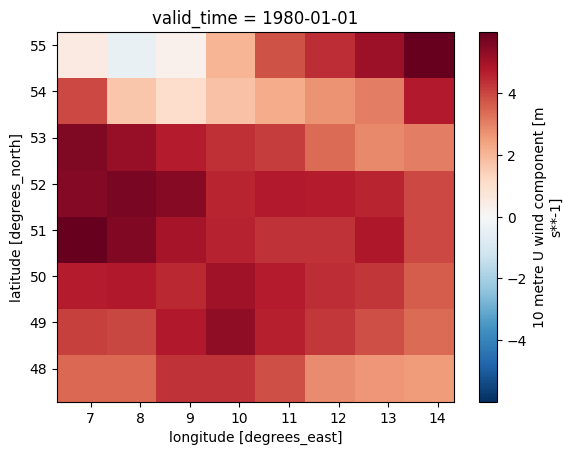

In [14]:
data_1980 = ds.sel(valid_time=slice("1980-01-01", "1980-12-31"))

def average_pooling_xr(hr_data, scale):
    return hr_data.coarsen(latitude=scale, longitude=scale, boundary='trim').mean()

pooled_data = average_pooling_xr(data_1980, 4)
# plot first timestep   
pooled_data.sel(valid_time="1980-01-01T00:00:00").u10.plot()


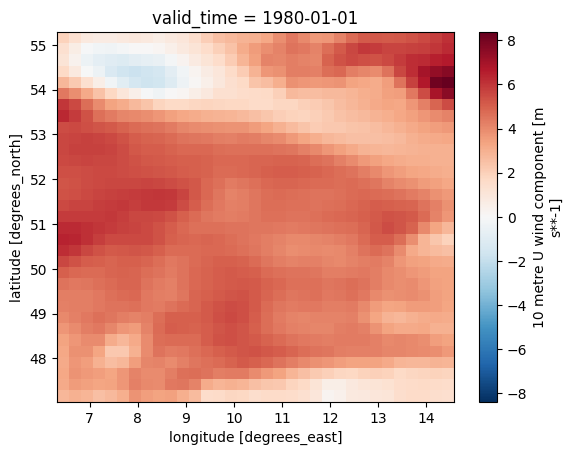

In [13]:
data_1980.sel(valid_time="1980-01-01T00:00:00").u10.plot()

In [5]:
#get all timesteps for 31.12.1983
print(ds.sel(valid_time="1983-12-31").valid_time)
# get all timesteps for 01.01.1984


<xarray.DataArray 'valid_time' (valid_time: 8)> Size: 64B
array(['1983-12-31T00:00:00.000000000', '1983-12-31T03:00:00.000000000',
       '1983-12-31T06:00:00.000000000', '1983-12-31T09:00:00.000000000',
       '1983-12-31T12:00:00.000000000', '1983-12-31T15:00:00.000000000',
       '1983-12-31T18:00:00.000000000', '1983-12-31T21:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 64B 1983-12-31 ... 1983-12-31T21:...
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T


In [4]:
years = np.random.randint(1980, 2014, 4)
train_years = years[:3]
test_year = years[3]
# select these years from the dataset
#mask = data['valid_time].dt.year.isin(years)

print(years)
dt = xr.open_dataset(DATA_PATH).isel(latitude=slice(0, 32), longitude=slice(0, 32))
dt = dt.sel(valid_time=dt['valid_time'].dt.year.isin(years))
sorted_dt = []
for year in years:
    sorted_dt.append(dt.sel(valid_time=dt['valid_time'].dt.year == year))
    
dl_selected = xr.concat(sorted_dt, dim='valid_time')

print(dl_selected)

train_data = dl_selected.sel(valid_time=dl_selected['valid_time'].dt.year.isin(train_years))


[2012 2007 2001 2012]
<xarray.Dataset> Size: 144MB
Dimensions:     (valid_time: 5848, latitude: 32, longitude: 32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 47kB 2012-01-01 ... 2012-12-31T18...
  * longitude   (longitude) float64 256B 6.45 6.7 6.95 7.2 ... 13.7 13.95 14.2
  * latitude    (latitude) float64 256B 55.16 54.91 54.66 ... 47.91 47.66 47.41
Data variables:
    u10         (valid_time, latitude, longitude) float32 24MB 3.492 ... 0.6047
    v10         (valid_time, latitude, longitude) float32 24MB 8.007 ... 2.24
    d2m         (valid_time, latitude, longitude) float32 24MB 281.2 ... 266.8
    t2m         (valid_time, latitude, longitude) float32 24MB 281.9 ... 267.9
    msl         (valid_time, latitude, longitude) float32 24MB 1.002e+05 ... ...
    tp          (valid_time, latitude, longitude) float32 24MB 0.0001908 ... 0.0
Attributes:
    CDI:                     Climate Data Interface version 2.0.5 (https://mp...
    Conventions:             CF-1.7
    insti

In [5]:
dataset = xr.open_dataset(DATA_PATH).sel(valid_time=slice('2020-01-01', '2020-01-02'))
print(dataset.variables)

Frozen({'valid_time': <xarray.IndexVariable 'valid_time' (valid_time: 8)> Size: 64B
array(['2020-01-01T00:00:00.000000000', '2020-01-01T06:00:00.000000000',
       '2020-01-01T12:00:00.000000000', '2020-01-01T18:00:00.000000000',
       '2020-01-02T00:00:00.000000000', '2020-01-02T06:00:00.000000000',
       '2020-01-02T12:00:00.000000000', '2020-01-02T18:00:00.000000000'],
      dtype='datetime64[ns]')
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T, 'longitude': <xarray.IndexVariable 'longitude' (longitude: 33)> Size: 264B
array([ 6.45,  6.7 ,  6.95,  7.2 ,  7.45,  7.7 ,  7.95,  8.2 ,  8.45,  8.7 ,
        8.95,  9.2 ,  9.45,  9.7 ,  9.95, 10.2 , 10.45, 10.7 , 10.95, 11.2 ,
       11.45, 11.7 , 11.95, 12.2 , 12.45, 12.7 , 12.95, 13.2 , 13.45, 13.7 ,
       13.95, 14.2 , 14.45])
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X, 'latitude': <xarray.IndexVariable 'latitude' 

In [6]:

dataset.data_vars


Data variables:
    u10      (valid_time, latitude, longitude) float32 35kB ...
    v10      (valid_time, latitude, longitude) float32 35kB ...
    d2m      (valid_time, latitude, longitude) float32 35kB ...
    t2m      (valid_time, latitude, longitude) float32 35kB ...
    msl      (valid_time, latitude, longitude) float32 35kB ...
    tp       (valid_time, latitude, longitude) float32 35kB ...

In [7]:
for var in dataset:
    print(var)

u10
v10
d2m
t2m
msl
tp


In [8]:
def get_wind_speed(u, v):
    func = lambda x, y: np.sqrt(x**2 + y**2)
    return xr.apply_ufunc(func, u, v)

In [9]:
print(list(dataset.variables)[5:])

['d2m', 't2m', 'msl', 'tp']


In [10]:
dataset['u10'][0, :32, :32].values.shape

(32, 32)

In [11]:
test = np.array([dataset[var][0, :32, :32].values for var in list(dataset.variables)[5:]])
print(test.shape)

(4, 32, 32)


In [12]:
u10 = dataset['u10'][:, :32, :32]
v10 = dataset['v10'][:, :32, :32]
# add wind speed
wind_speed = get_wind_speed(u10, v10)
print(wind_speed)

<xarray.DataArray (valid_time: 8, latitude: 32, longitude: 32)> Size: 33kB
array([[[ 5.228447  ,  5.138687  ,  5.1074195 , ...,  8.031779  ,
          7.867828  ,  7.7976556 ],
        [ 4.868079  ,  4.762705  ,  4.6951246 , ...,  8.6730175 ,
          8.533914  ,  8.312901  ],
        [ 4.4959393 ,  4.4065704 ,  4.322227  , ...,  8.293587  ,
          8.313567  ,  8.427291  ],
        ...,
        [ 3.0372186 ,  2.7386472 ,  1.2823232 , ...,  0.94917655,
          1.1161265 ,  1.239449  ],
        [ 3.1976278 ,  2.904613  ,  1.5843053 , ...,  1.3322664 ,
          1.4205359 ,  1.5028625 ],
        [ 3.0062776 ,  2.711911  ,  1.8802997 , ...,  1.079965  ,
          1.5873934 ,  1.9574336 ]],

       [[ 8.023698  ,  7.975404  ,  8.000065  , ...,  9.2618685 ,
          9.298133  ,  9.456752  ],
        [ 7.602591  ,  7.536484  ,  7.540251  , ...,  9.5950165 ,
          9.694255  ,  9.7182    ],
        [ 7.168791  ,  7.0982146 ,  7.07836   , ...,  8.899332  ,
          9.120132  ,  9.384

In [13]:
if not os.path.exists('data/images'):
    os.makedirs('data/images')

In [14]:
#rescale to 0-1
#change to -1 to 1

min_max_scaler = preprocessing.MinMaxScaler(feature_range=(-1, 1))
data_arr = []
#create 32x32 images of windspeed
for i, data  in enumerate(wind_speed):
    data = data.values
    data = min_max_scaler.fit_transform(data)
    data = np.uint8(data * 255)
    data_arr.append(data)
    img = Image.fromarray(data)
    
    img.save(f'data/images/hr_{i}.png')

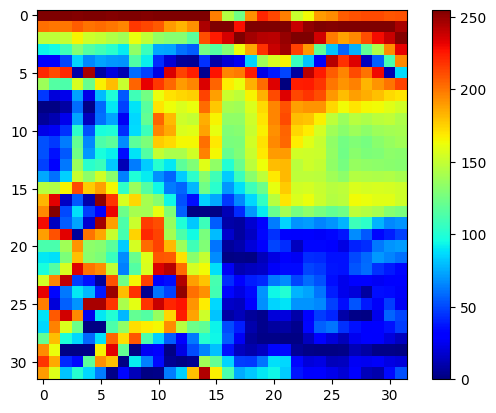

In [15]:
#make colormap of wind speed
plt.imshow(data_arr[0], cmap='jet', interpolation='nearest')
plt.colorbar()

In [16]:
# Low resolution images, apply average pooling of 2x2
def average_pooling(data, scale):
    new_h, new_w = data.shape[0]//scale, data.shape[1]//scale
    
    data = data.reshape(new_h,scale ,new_w,scale).mean(axis=(1, 3))
    # to uint8
    data = np.uint8(data)
    return data

data_arr_lr_2 = []

for i,data in enumerate(data_arr):

    data = average_pooling(data, 2)
    data_arr_lr_2.append(data)
    img = Image.fromarray(data)
    img.save(f'data/images/lr_2x2_{i}.png')
data_arr_lr_8 = []  
for i, data in enumerate(data_arr):
    data = average_pooling(data, 8)
    img = Image.fromarray(data)
    data_arr_lr_8.append(data)
    img.save(f'data/images/lr_8x8_{i}.png')
    


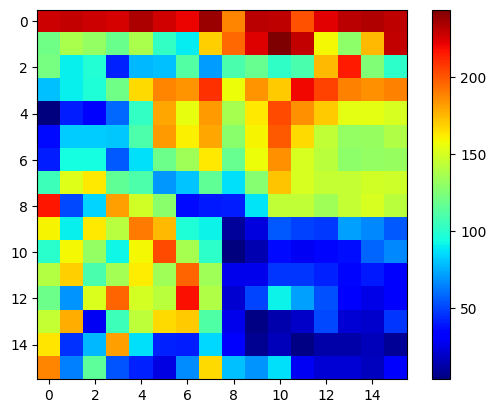

In [17]:
plt.imshow(data_arr_lr_2[0], cmap='jet', interpolation='nearest')
plt.colorbar()


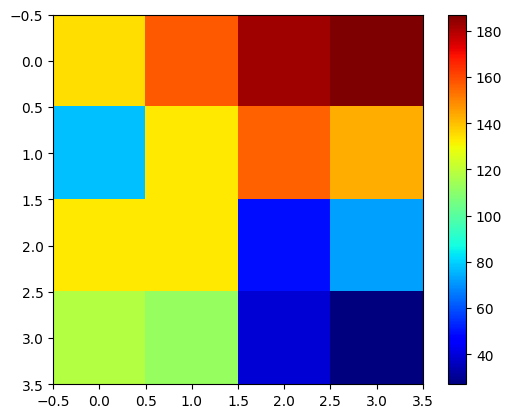

In [18]:
plt.imshow(data_arr_lr_8[0], cmap='jet', interpolation='nearest')
plt.colorbar()

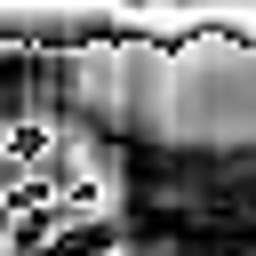

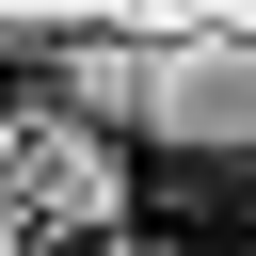

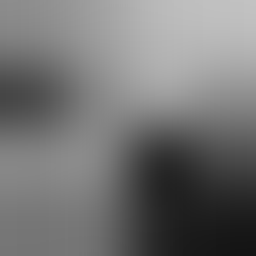

In [19]:
display(Image.open('data/images/hr_0.png').resize((256, 256)))
display(Image.open('data/images/lr_2x2_0.png').resize((256, 256)))
display(Image.open('data/images/lr_8x8_0.png').resize((256, 256)))

huggingface_hub version >0.24 does not work with super_image

In [20]:
import huggingface_hub
assert(huggingface_hub.__version__ == "0.24.0")

In [21]:
from datasets import load_dataset
from super_image import Trainer, TrainingArguments, EdsrModel, EdsrConfig
import torch
from torch.utils.data import Dataset
import torch.nn as nn

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale = 2
config = EdsrConfig(scale=2)
model = EdsrModel(config).to(device)

In [ ]:
#from Lucas' code, modify model to fit grayscale data

class MeanShift(nn.Conv2d):
    def __init__(self, rgb_range, rgb_mean=0.5, rgb_std=1.0, sign=-1):
        # modify kernel to size 1 for single input channel
        super(MeanShift, self).__init__(1, 1, kernel_size=1)

        # adjust weight and bias for a single input channel
        std = torch.Tensor([rgb_std])
        self.weight.data = torch.eye(1).view(1, 1, 1, 1)
        self.weight.data.div_(std.view(1, 1, 1, 1))
        self.bias.data = sign * rgb_range * torch.Tensor([rgb_mean])
        self.bias.data.div_(std)
        self.requires_grad = False


# values
rgb_range = 255.0
rgb_mean_value = 0.5
rgb_stdev = 1.0

# create instance of Meanshift
mean_shift_module = MeanShift(rgb_range, rgb_mean_value, rgb_stdev)


# modify
model.sub_mean = MeanShift(rgb_range, rgb_mean=rgb_mean_value, rgb_std=rgb_stdev)
model.add_mean = MeanShift(rgb_range, sign=1, rgb_mean= rgb_mean_value, rgb_std=rgb_stdev)
model.head = torch.nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

model.tail = torch.nn.Sequential(
            torch.nn.Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            torch.nn.PixelShuffle(upscale_factor=2),
            torch.nn.Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [24]:
model

EdsrModel(
  (sub_mean): MeanShift(1, 1, kernel_size=(1, 1), stride=(1, 1))
  (add_mean): MeanShift(1, 1, kernel_size=(1, 1), stride=(1, 1))
  (head): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): ResBlock(
      (body): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResBlock(
      (body): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (2): ResBlock(
      (body): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (3): ResBlo

In [ ]:
DATA_PATH_2 = '../../data/merge_atlantic_data.nc'

dataset2 = xr.open_dataset(DATA_PATH_2).isel(latitude=slice(0, 32), longitude=slice(0, 32))
dataset1 = xr.open_dataset(DATA_PATH).isel(latitude=slice(0, 32), longitude=slice(0, 32))

# print shape
print(dataset1['u10'].shape)
print(dataset2['u10'].shape)

u10 = dataset2['u10'][:, :32, :32]

print(u10.shape)



(64284, 32, 32)
(64284, 32, 32)
(64284, 32, 32)


In [42]:
print(dataset1.dims)

FrozenMappingWarningOnValuesAccess({'valid_time': 64284, 'longitude': 32, 'latitude': 32})


In [37]:
for data in u10[:10]:
    data = data.values
    lr = average_pooling(data, 4)
   

print(f"Dataset dimensions: {dataset2.dims}")
for var in dataset2.data_vars:
    print(f"Variable '{var}' shape: {dataset2[var].shape}")

print(f"Dataset dimensions: {dataset1.dims}")
for var in dataset1.data_vars:
    print(f"Variable '{var}' shape: {dataset1[var].shape}")
    
    
for var in ['u10', 'v10', 't2m']:
    print(f"{var}: NaN count = {np.isnan(dataset2[var].values).sum()}")

Dataset dimensions: FrozenMappingWarningOnValuesAccess({'valid_time': 64284, 'longitude': 32, 'latitude': 32})
Variable 'u10' shape: (64284, 32, 32)
Variable 'v10' shape: (64284, 32, 32)
Variable 't2m' shape: (64284, 32, 32)
Dataset dimensions: FrozenMappingWarningOnValuesAccess({'valid_time': 64284, 'longitude': 32, 'latitude': 32})
Variable 'u10' shape: (64284, 32, 32)
Variable 'v10' shape: (64284, 32, 32)
Variable 'd2m' shape: (64284, 32, 32)
Variable 't2m' shape: (64284, 32, 32)
Variable 'msl' shape: (64284, 32, 32)
Variable 'tp' shape: (64284, 32, 32)
u10: NaN count = 0
v10: NaN count = 0
t2m: NaN count = 0
